# Tutorial 5

# The Logical Flow of the Course

Our course follows a problem-solution progression, with each topic building on the last.

### 1. First, the Toolkit (Math Foundations)
* We start with **Linear Algebra** as the fundamental language for machine learning.
    * **Vectors & Matrices** are used to represent data points and entire datasets.
    * The equation **`Xw = y`** is the core mathematical structure for building linear models.
* We then learn about **Gradients** as the primary tool for optimization—finding the "best" model parameters by minimizing an error function.

### 2. Then, the First Model (Linear Regression)
* With the math tools, we tackle our first practical problem: **Linear Regression**.
    * The goal is to fit a line to the data by minimizing the prediction error.
    * This error is calculated using the **Least Squares** method.
    * For this simple model, we can find the perfect solution directly using a **"closed-form" formula**.

### 3. Next, a Complication (Polynomial Regression)
* We realize that a straight line is often too simple to model real-world data.
    * To fit curves, we introduce **Polynomial Regression**.
    * The key idea is to create new, higher-order features (like `x²`, `x³`) from the original ones and then apply the same linear regression logic.

### 4. Which Leads to a Core Problem (Overfitting)
* Using more complex models like high-order polynomials introduces a new risk.
    * This risk is **Overfitting**: the model learns the training data perfectly (including the noise) but performs poorly on new, unseen test data.
    * This highlights the fundamental **Bias-Variance Trade-off**: simple models tend to have high bias (underfitting), while complex models tend to have high variance (overfitting).

### 5. So, a Solution for Overfitting (Regularization)
* To prevent our complex models from overfitting, we need a way to control their complexity.
    * The general technique is called **Regularization**.
    * We learn a specific method, **Ridge Regression**, which adds a penalty term to the cost function.
    * This penalty discourages the model's weights from becoming too large, resulting in a simpler, smoother, and more generalizable model.

### 6. And a More General Way to Solve (Gradient Descent)
* We learn that the "closed-form" solution is a luxury that doesn't exist for most advanced models.
    * For these cases, we need a more universal optimization algorithm: **Gradient Descent**.
    * It's an iterative process that starts with a random guess and repeatedly takes small steps in the direction of the steepest descent (the negative gradient) to find the minimum of the cost function.

### 7. Finally, a Different Approach (Trees)
* After focusing on equation-based models, we explore a completely different, rule-based paradigm.
    * The **Decision Tree** model makes predictions by learning a series of simple if-else rules.
    * We find that a single tree can be unstable and prone to overfitting.
    * The solution is to use a **Random Forest**, which is an ensemble (or "forest") of many decision trees. By combining their predictions, we get a much more robust and accurate final model.

### Linear Regression Review

- **From Linear Systems to Regression**
  - We are building on our knowledge of linear systems to solve regression problems.
  - Regression is a core task within **Supervised Learning**, alongside classification.

- **Data Structure in Supervised Learning**
  - **Dataset**: A collection of `m` data points or samples.
  - **Features (X)**: Each data point (`xᵢ`) is represented by a `d`-dimensional feature vector.
    - `m` = number of samples (corresponds to the number of equations).
    - `d` = number of features (corresponds to the number of unknowns).
  - **Target (y)**: For regression, each `xᵢ` has a corresponding continuous, real-valued target, `yᵢ`.

- **The Linear Regression Model & How to Solve It**
  - **Model**: We aim to find a model that uses the input `X` to predict `y`, based on the familiar linear system equation: $Xw = y$.
  - **The Problem**: In machine learning, we typically have more samples than features (`m > d`), which creates an **overdetermined system** that usually has no exact solution.
  - **The Solution**: We reframe this as an **optimization problem**, where the goal is to **minimize a Loss Function**.
    - **Loss Function**: We use **Squared Error Loss**, which minimizes the squared difference between the predicted value and the true value:
      $$J(w) = \sum (Xw - y)^2$$
      - Here, $Xw$ represents the model's prediction, often denoted as $\hat{y}$.

- **The Design Matrix**
  - The `X` matrix we use in linear regression is slightly different from the one in a standard linear system.
  - It's called a **biased design matrix**, and its dimension is `m x (d+1)`.
  - We add a column of all ones to the original feature matrix. This column is used to learn the model's **bias term** (the intercept).

- **Solving the Optimization Problem**
  - **Method**: To minimize the loss function $J(w)$, we calculate its partial derivative with respect to `w` and set it to zero:
    $$\frac{\partial J(w)}{\partial w} = 0$$
  - **Closed-form Solution**: For linear regression with a least squares loss, this optimization has a direct analytical solution. The solution is derived using the **left inverse**:
    $$\hat{w} = (X^T X)^{-1} X^T y$$
  - **Gradient Descent**: For more complex models (like neural networks) where a closed-form solution isn't available, we use iterative methods like **Gradient Descent**. This will be covered in future lectures (e.g., Lecture 8).

- **Handling Multiple Outputs**
  - The same linear regression framework can be used for problems with **multiple outputs**.
  - In this case, the target `Y` becomes an `m x k` matrix, where `k` is the number of outputs for each sample.
  - The solution formula remains exactly the same, but `Y` is now a matrix, and the resulting parameter $\hat{W}$ will also be a matrix with dimensions `(d+1) x k`.

### Question 1

Given the following data pairs for training:

\begin{split}
\{x = -10\} &\rightarrow \{y = 5\} \\
\{x = -8\} &\rightarrow \{y = 5\} \\
\{x = -3\} &\rightarrow \{y = 4\} \\
\{x = -1\} &\rightarrow \{y = 3\} \\
\{x = 2\} &\rightarrow \{y = 2\} \\
\{x = 8\} &\rightarrow \{y = 2\}
\end{split}

(a) Perform a linear regression with addition of a bias/offset term to the input feature vector and sketch the result of line fitting.  

(b) Perform a linear regression without inclusion of any bias/offset term and sketch the result of line fitting.  

(c) What is the effect of adding a bias/offset term to the input feature vector?

(a) This is an over-determined system.

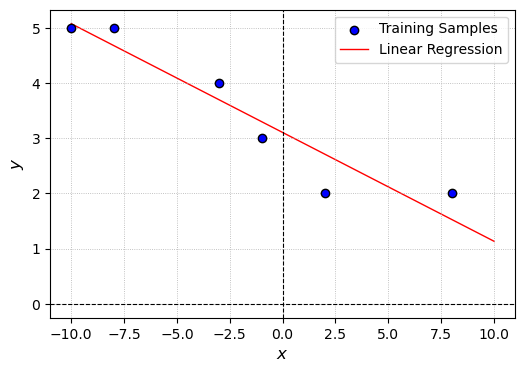

Linear regression with bias weights: [[ 3.10550459]
 [-0.19724771]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Given data
X_raw = np.array([-10, -8, -3, -1, 2, 8])
y = np.array([[5], [5], [4], [3], [2], [2]])
# y = np.array([5, 5, 4, 3, 2, 2])

# Adding bias term
X_bias = np.vstack((np.ones_like(X_raw), X_raw)).T

# Compute weights using normal equation
w_bias = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

# Generate predictions
x_range = np.linspace(-10, 10, 100)  # Continuous x range
X_pred = np.vstack((np.ones_like(x_range), x_range)).T
y_pred_bias = X_pred @ w_bias

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(X_raw, y, color='blue', edgecolors='black', label="Training Samples", zorder=2)
plt.plot(x_range, y_pred_bias, color='red', linewidth=1, label="Linear Regression", zorder=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)  # Dashed vertical line at x=0
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)  # Dashed horizontal line at y=0
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$y$', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', linewidth=0.6)
plt.show()

print("Linear regression with bias weights:", w_bias)


## Understanding `np.ones_like`, `np.ones`, `np.vstack`, and `np.hstack`

Before applying these functions to construct a bias term for a dataset, let's first understand what each of them does independently.

---

### **1. `np.ones_like` vs. `np.ones`**
Both functions generate arrays filled with ones, but they behave differently in terms of shape.

#### **🔹 `np.ones_like`**
`np.ones_like(x)` creates an array of ones with the same shape and type as `x`.

Example:


In [2]:
x = np.array([-10, -8, -3, -1, 2, 8])
ones_like_x = np.ones_like(x)
print(ones_like_x)

[1 1 1 1 1 1]


- If `x` is a 1D array with shape `(6,)`, `np.ones_like(x)` also has shape `(6,)`.

#### **🔹 `np.ones`**
`np.ones(shape)` creates an array of ones with a specified shape.

Example:


In [3]:
ones_explicit = np.ones((6, 1))
print(ones_explicit)

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


- `np.ones((6,1))` explicitly creates a **column vector** of ones.
- **Difference from `np.ones_like(x)`**:  
  - `np.ones_like(x)` keeps the same shape as `x` (1D if `x` is 1D).
  - `np.ones((6,1))` forces a **column vector**, ensuring `(6,1)` shape.

---

### **2. `np.vstack` vs. `np.hstack`**
These functions are used for stacking arrays together in different ways.

#### **🔹 `np.vstack` (Vertical Stacking)**
`np.vstack((array1, array2))` stacks arrays **row-wise**.

Example:


In [4]:
x = np.array([-10, -8, -3, -1, 2, 8])
ones = np.ones_like(x)
stacked_v = np.vstack((ones, x))
print(stacked_v)

[[  1   1   1   1   1   1]
 [-10  -8  -3  -1   2   8]]


- The result is a **2-row matrix**, but we need a column format.
- To fix this, we **transpose** it using `.T`:



In [5]:
X_bias_vstack = np.vstack((ones, x)).T
print(X_bias_vstack)



[[  1 -10]
 [  1  -8]
 [  1  -3]
 [  1  -1]
 [  1   2]
 [  1   8]]


- After `.T`, the shape becomes **(6,2)**, which is what we need.

#### **🔹 `np.hstack` (Horizontal Stacking)**
`np.hstack((array1, array2))` stacks arrays **column-wise**.

Example:


In [6]:
x_col = x.reshape(-1, 1) # Convert 1D array to 2D column vector
ones_col = np.ones((x.shape[0], 1)) # (6,1) column vector
stacked_h = np.hstack((ones_col, x_col))
print(stacked_h)

[[  1. -10.]
 [  1.  -8.]
 [  1.  -3.]
 [  1.  -1.]
 [  1.   2.]
 [  1.   8.]]


- `hstack` **directly produces** the correct **(6,2)** shape.
- This method is **more intuitive and generalizable**, especially for multi-dimensional `X`.



## **Understanding `reshape()` in NumPy**

The `reshape()` function in NumPy is used to change the shape of an array without modifying its data. It is especially useful when converting between **1D vectors**, **column vectors**, and **matrices**.

---

### **1. Why Use `reshape()`?**
NumPy treats `np.array([1, 2, 3])` as a **1D array with shape `(3,)`**, but some operations (e.g., matrix multiplication, `hstack()`, ML models) require explicit dimensions such as `(3,1)` for column vectors.

For example, when adding a bias term to `X`, we need `X` as a **2D matrix**, not a **1D vector**.

---

### **2. Basic Usage of `reshape()`**
The syntax for `reshape()` is: `array.reshape(new_shape)`  
where `new_shape` is a tuple defining the desired dimensions.

#### **🔹 Example 1: Converting a 1D array to a column vector (2D)**



In [7]:
x = np.array([1, 2, 3, 4]) # Shape: (4,)
x_col = x.reshape(4, 1) # Shape: (4,1)
print(x_col)

[[1]
 [2]
 [3]
 [4]]



#### **🔹 Example 2: Converting a 1D array to a row vector (2D)**


In [8]:
x_row = x.reshape(1, 4) # Shape: (1,4)
print(x_row)

[[1 2 3 4]]



---

### **3. `reshape(-1, 1)`: Automatic Dimension Inference**
Instead of manually specifying the number of rows, we can use `-1` to let NumPy **infer** the appropriate value.

#### **🔹 Example: Automatically determining the number of rows**


In [9]:
x = np.array([10, 20, 30, 40, 50, 60]) # Shape: (6,) 
x_col = x.reshape(-1, 1) # Reshape into (6,1) column vector 
print(x_col)


[[10]
 [20]
 [30]
 [40]
 [50]
 [60]]


- The `-1` tells NumPy: **"Determine the number of rows automatically."**
- Since we want **one column**, we specify `1` in the second dimension.
- NumPy automatically calculates the missing value (`6` in this case).

---


(b) This is an over-determined system.

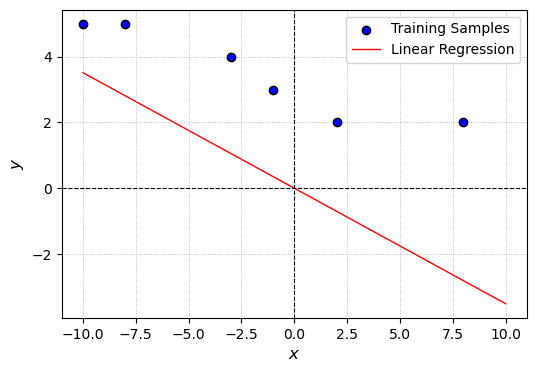

Linear regression without bias weights: [[-0.35123967]]


In [10]:
# Compute weights without bias
X_no_bias = X_raw.reshape(-1, 1)  # Reshape to column vector
w_no_bias = np.linalg.inv(X_no_bias.T @ X_no_bias) @ X_no_bias.T @ y

# Generate predictions
y_pred_no_bias = x_range.reshape(-1, 1) @ w_no_bias

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(X_raw, y, color='blue', edgecolors='black', label="Training Samples", zorder=2)
plt.plot(x_range, y_pred_no_bias, color='red', linewidth=1, label="Linear Regression", zorder=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)  # Dashed vertical line at x=0
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)  # Dashed horizontal line at y=0
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$y$', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', linewidth=0.6)
plt.show()

print("Linear regression without bias weights:", w_no_bias)


#### (c) The bias/offset term allows the line to move away from the origin (moved vertically in this case).

### Question 2

Given the following data pairs for training:  


\begin{split}
\{x_1 = 1, x_2 = 0, x_3 = 1\} &\rightarrow \{y = 1\} \\
\{x_1 = 2, x_2 = -1, x_3 = 1\} &\rightarrow \{y = 2\} \\
\{x_1 = 1, x_2 = 1, x_3 = 5\} &\rightarrow \{y = 3\}
\end{split}

(a) Predict the following test data without inclusion of an input bias/offset term.  

(b) Predict the following test data with inclusion of an input bias/offset term.  

\begin{split}
\{x_1 = -1, x_2 = 2, x_3 = 8\} &\rightarrow \{y = ?\} \\
\{x_1 = 1, x_2 = 5, x_3 = -1\} &\rightarrow \{y = ?\}
\end{split}

(a) Without bias, this is an **even-determined** system and **X** is invertible.

In [1]:
import numpy as np

# Given training data with bias term added
X = np.array([[1, 0, 1],  # Adding a bias term (1st column of ones)
              [2, -1, 1],
              [1, 1, 5]])

y = np.array([[1], [2], [3]])

# Compute w using the least squares method for the under-determined system
w = np.linalg.inv(X) @ y

# Given test data with bias term
X_test = np.array([[-1, 2, 8],  # Adding bias term to test data
                   [1, 5, -1]])

# Predict y for test data
y_pred = X_test @ w

# Display results
w, y_pred


(array([[ 0.33333333],
        [-0.66666667],
        [ 0.66666667]]),
 array([[ 3.66666667],
        [-3.66666667]]))

(b) After adding bias, it becomes an **under-determined** system.

In [12]:
import numpy as np

# Given training data with bias term added
X = np.array([[1, 1, 0, 1],  # Adding a bias term (1st column of ones)
              [1, 2, -1, 1],
              [1, 1, 1, 5]])

y = np.array([[1], [2], [3]])

# Compute w using the least squares method for the under-determined system
w = X.T @ np.linalg.inv(X @ X.T) @ y

# Given test data with bias term
X_test = np.array([[1, -1, 2, 8],  # Adding bias term to test data
                   [1, 1, 5, -1]])

# Predict y for test data
y_pred = X_test @ w

# Display results
w, y_pred


(array([[-0.14285714],
        [ 0.52380952],
        [-0.47619048],
        [ 0.61904762]]),
 array([[ 3.33333333],
        [-2.61904762]]))

### Question 3

A college bookstore must order books two months before each semester starts. They believe that the number of books that will ultimately be sold for any particular course is related to the number of students registered for the course when the books are ordered. They would like to develop a linear regression equation to help plan how many books to order. 

From past records, the bookstore obtains the number of students registered, **X**, and the number of books actually sold for a course, **Y**, for 12 different semesters. These data are shown below.

| Semester | Students (X) | Books Sold (Y) |
|----------|------------|---------------|
| 1        | 36         | 31            |
| 2        | 28         | 29            |
| 3        | 35         | 34            |
| 4        | 39         | 35            |
| 5        | 30         | 29            |
| 6        | 30         | 30            |
| 7        | 31         | 30            |
| 8        | 38         | 38            |
| 9        | 36         | 34            |
| 10       | 38         | 33            |
| 11       | 29         | 29            |
| 12       | 26         | 26            |

#### Tasks:
- **(a)** Obtain a scatter plot of the number of books sold versus the number of registered students.
- **(b)** Write down the regression equation and calculate the coefficients for this fitting.
- **(c)** Predict the number of books that would be sold in a semester when **30** students have registered.
- **(d)** Predict the number of books that would be sold in a semester when **5** students have registered.


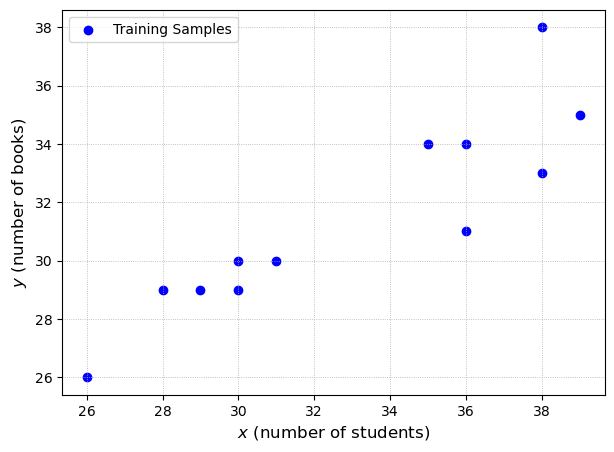

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Given data
students = np.array([36, 28, 35, 39, 30, 30, 31, 38, 36, 38, 29, 26])
books = np.array([31, 29, 34, 35, 29, 30, 30, 38, 34, 33, 29, 26])

# Scatter plot
plt.figure(figsize=(7,5))
plt.scatter(students, books, color='blue', label="Training Samples")
plt.xlabel(r'$x$ (number of students)', fontsize=12)
plt.ylabel(r'$y$ (number of books)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', linewidth=0.6)
plt.show()


(b) Regression equation: $y = Xw$  
$$ w = (X^T X)^{-1} X^T  y $$

In [14]:
# Adding bias term to X
X = np.vstack((np.ones_like(students), students)).T  # Shape (12,2)
y = books.reshape(-1,1)  # Shape (12,1)

# Compute weights using normal equation w = (X^T * X)^(-1) * X^T * y
w = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated Coefficients (w):\n", w)


Estimated Coefficients (w):
 [[9.3       ]
 [0.67272727]]


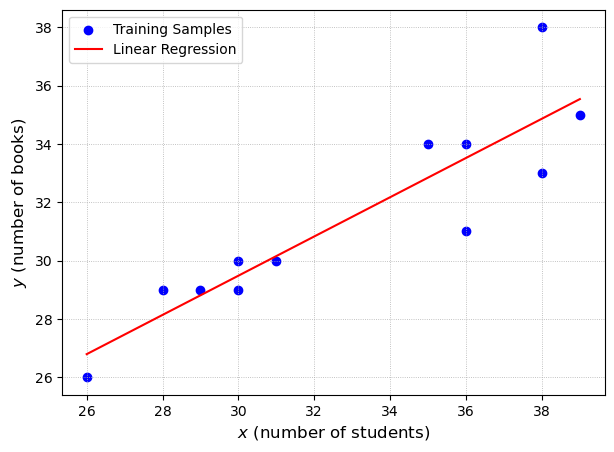

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Generate predictions for the fitted line
x_range = np.linspace(min(students), max(students), 100)
X_pred = np.vstack((np.ones_like(x_range), x_range)).T
y_pred = X_pred @ w

# Plot scatter plot of training data
plt.figure(figsize=(7, 5))
plt.scatter(students, books, color='blue', label="Training Samples")
plt.plot(x_range, y_pred, color='red', label="Linear Regression")

# Labels and title
plt.xlabel(r'$x$ (number of students)', fontsize=12)
plt.ylabel(r'$y$ (number of books)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', linewidth=0.6)

# Show the plot
plt.show()


(c) Prediction: $\hat{y}_t = X_t \hat{w}$


In [16]:
# Predict y when students = 30
X_test = np.array([[1, 30]])  # Adding bias term
y_pred_30 = X_test @ w
print("Predicted books for 30 students:", y_pred_30)


Predicted books for 30 students: [[29.48181818]]


(d) Similar to (c)

In [17]:
# Predict y when students = 5
X_test_5 = np.array([[1, 5]])  # Adding bias term
y_pred_5 = X_test_5 @ w
print("Predicted books for 5 students:", y_pred_5)


Predicted books for 5 students: [[12.66363636]]


This prediction appears to be somewhat over optimistic. Since 5 students is not within the range 
of the sampled number of students, it might not be appropriate to use the regression equation to make this prediction. 
We do not know if the straight-line model would fit data at this point, and we might not want to extrapolate far beyond 
the observed range.

### Question 4

Repeat the above problem using the following training data:

| Semester | Students | Books |
|----------|----------|-------|
| 1        | 36       | 31    |
| 2        | 26       | 20    |
| 3        | 35       | 34    |
| 4        | 39       | 35    |
| 5        | 26       | 20    |
| 6        | 30       | 30    |
| 7        | 31       | 30    |
| 8        | 38       | 38    |
| 9        | 36       | 34    |
| 10       | 38       | 33    |
| 11       | 26       | 20    |
| 12       | 26       | 20    |

#### Tasks:
- **(a)** Calculate the regression coefficients for this fitting.  

- **(b)** Predict the number of books that would be sold in a semester when **30 students** have registered.  

- **(c)** Purge those duplicating data and re-fit the line and observe the impact on predicting the number of books that would be sold in a semester when **30 students** have registered.  

- **(d)** Sketch and compare the two fitting lines.  


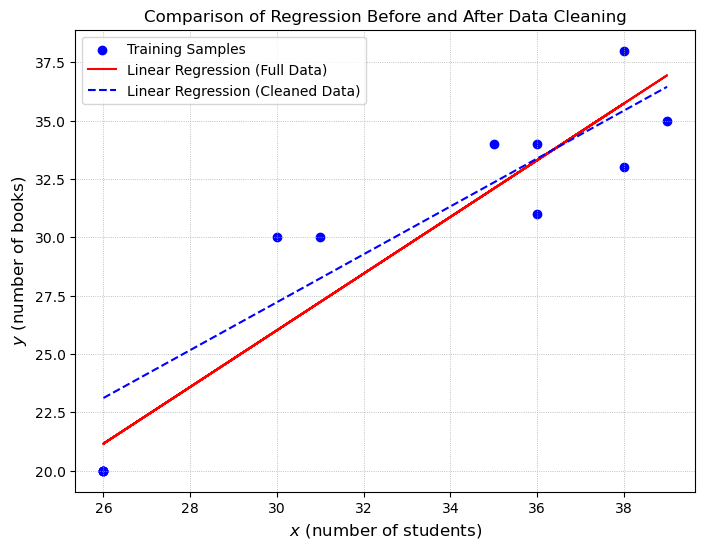

Regression Coefficients (Full Data): w0 = -10.4126, w1 = 1.2143
Prediction for 30 students (Full Data): 26.0177

Regression Coefficients (Cleaned Data): w0 = -3.5584, w1 = 1.0260
Prediction for 30 students (Cleaned Data): 27.2208


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Given training data
students = np.array([36, 26, 35, 39, 26, 30, 31, 38, 36, 38, 26, 26])
books = np.array([31, 20, 34, 35, 20, 30, 30, 38, 34, 33, 20, 20])

# Add bias term
X_full = np.vstack((np.ones_like(students), students)).T
y_full = books.reshape(-1, 1)

# Compute regression coefficients using normal equation
w_full = np.linalg.inv(X_full.T @ X_full) @ X_full.T @ y_full

# Predict for 30 students using full dataset
X_test = np.array([[1, 30]])
y_pred_full = X_test @ w_full

# Remove duplicate data
unique_indices = np.unique(np.column_stack((students, books)), axis=0, return_index=True)[1]
students_clean = students[unique_indices]
books_clean = books[unique_indices]

# Recompute regression with cleaned data
X_clean = np.vstack((np.ones_like(students_clean), students_clean)).T
y_clean = books_clean.reshape(-1, 1)
w_clean = np.linalg.inv(X_clean.T @ X_clean) @ X_clean.T @ y_clean

# Predict for 30 students using cleaned dataset
y_pred_clean = X_test @ w_clean

# Plot data points and regression lines
plt.figure(figsize=(8,6))
plt.scatter(students, books, color='blue', label="Training Samples")
plt.plot(students, X_full @ w_full, 'r-', label="Linear Regression (Full Data)")
plt.plot(students_clean, X_clean @ w_clean, 'b--', label="Linear Regression (Cleaned Data)")
plt.xlabel(r'$x$ (number of students)', fontsize=12)
plt.ylabel(r'$y$ (number of books)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', linewidth=0.6)

plt.title("Comparison of Regression Before and After Data Cleaning")
plt.show()

# Print results
print(f"Regression Coefficients (Full Data): w0 = {w_full[0,0]:.4f}, w1 = {w_full[1,0]:.4f}")
print(f"Prediction for 30 students (Full Data): {y_pred_full[0,0]:.4f}")

print(f"\nRegression Coefficients (Cleaned Data): w0 = {w_clean[0,0]:.4f}, w1 = {w_clean[1,0]:.4f}")
print(f"Prediction for 30 students (Cleaned Data): {y_pred_clean[0,0]:.4f}")


#### **Note**: these results show that duplicating samples can influence the learning and decision too. In this case, purging seems to give a more optimistic prediction for a relatively small number of students (< 37) and more conservative prediction for a relatively large number of students (>37)

### Q5

Download the data file “government-expenditure-on-education.csv” from Canvas Tutorial Folder. 
It depicts the government’s educational expenditure over the years (downloaded in July 2021 from 
https://data.gov.sg/dataset/government-expenditure-on-education)
Predict the educational expenditure of year 2021 based on linear regression. Solve the problem using Python with a 
plot. Note: please use the file from the canvas link.
Hint: use Python packages like numpy, pandas, matplotlib.pyplot, numpy.linalg

Regression Coefficients: w0 (intercept) = -648432470.4935, w1 (slope) = 326835.9103


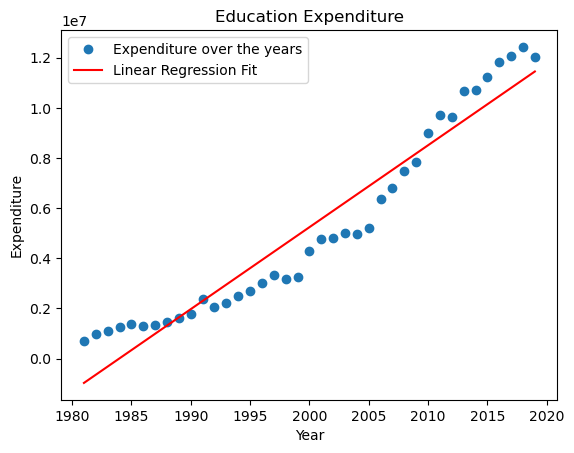

Predicted expenditure for 2021: 12102904.2706


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv

# Load dataset from CSV file
df = pd.read_csv("government-expenditure-on-education.csv")

# Extract 'recurrent_expenditure_total' column as a list (target variable y)
expenditureList = df['recurrent_expenditure_total'].tolist()

# Extract 'year' column as a list (feature X)
yearList = df['year'].tolist()

# Construct matrix X with a bias term (column of ones) for linear regression
m_list = [[1] * len(yearList), yearList]  # First row: all ones (bias), second row: years
X = np.array(m_list).T  # Convert to NumPy array and transpose it to match (n×2) shape

# Convert expenditure list to NumPy array (output variable y)
y = np.array(expenditureList)

# Compute the linear regression weights using the normal equation: w = (Xᵀ X)⁻¹ Xᵀ y
w = inv(X.T @ X) @ X.T @ y

print(f"Regression Coefficients: w0 (intercept) = {w[0]:.4f}, w1 (slope) = {w[1]:.4f}")

# Compute the fitted values using the obtained regression model
y_line = X.dot(w)  # ŷ = Xw

# 'o' is the marker style, which means each data point is represented as a circular marker.
# Since no line style is specified, Matplotlib will only plot points, making it look like a scatter plot.
plt.plot(yearList, expenditureList, 'o', label='Expenditure over the years')
plt.plot(yearList, y_line, label='Linear Regression Fit', color='red')
plt.xlabel('Year')
plt.ylabel('Expenditure')
plt.title('Education Expenditure')
plt.legend()
plt.show()

# Predict expenditure for the year 2021
y_predict = np.array([1, 2021]).dot(w)  # Use the computed weights to predict for x=2021
print(f"Predicted expenditure for 2021: {y_predict:.4f}")


### Question 6

Download the CSV file for red-wine using “ wine = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",sep=';') ” . Use Python to perform the following tasks. Hint: use Python 
packages like numpy, pandas, matplotlib.pyplot, numpy.linalg, and sklearn.metrics.


(a) Take `y = wine.quality` as the target output and `x = wine.drop('quality',axis = 1)` as 
the input features. Assume the given list of data is already randomly indexed (i.e., not in particular order), 
split the database into two sets: [0:1500]samples for regression training, and [1500:1599]samples for testing.


(b) Perform linear regression on the training set and print out the learned parameters.

(c) Perform prediction using the test set and provide the prediction accuracy in terms of the mean of squared
errors (MSE).

In [20]:
import pandas as pd
#import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import inv
from sklearn.metrics import mean_squared_error
# get data from web
wine = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",sep=';')
# wine.info()
# print(wine.head())

y = wine.quality
x = wine.drop('quality',axis = 1)

# Include the offset/bias term
x0 = np.ones((len(y),1))
X = np.hstack((x0,x))

# split data into training and test sets 
# (Note: this exercise introduces the basic protocol of using the training-test partitioning of samples for evaluation assuming the list of data is already randomly indexed)
# In case you really want a general random split to have a better training/test distributions:
# from sklearn.model_selection import train_test_split
# train_X,test_X,train_y,test_y = train_test_split(X,y,test_size=99/1599, random_state = 0)
train_X = X[0:1500]
train_y = y[0:1500]
test_X = X[1500:1599]
test_y = y[1500:1599]

# linear regression
w = inv(train_X.T @ train_X) @ train_X.T @ train_y
print(w)

yt_est = test_X.dot(w)

MSE = np.square(np.subtract(test_y,yt_est)).mean()
print(MSE)
MSE = mean_squared_error(test_y,yt_est)
print(MSE)

[ 2.22330327e+01  2.68702621e-02 -1.12838019e+00 -2.06141685e-01
  1.22000584e-02 -1.77718503e+00  4.29357454e-03 -3.18953315e-03
 -1.81795124e+01 -3.98142390e-01  8.92474793e-01  2.77147239e-01]
0.34352638121356655
0.34352638121356655


### Question 9

The values of feature vector x and their corresponding values of target vector y are shown in the table below:


| **x**   | [3, -1, 0] | [5, 1, 2] | [9, -1, 3] | [-6, 7, 2] | [3, -2, 0] |
|---------|------------|-----------|------------|------------|------------|
| **y**   | **[1, -1]**  | **[-1, 0]**   | **[1, 2]**     | **[0, 3]**     | **[1, -2]**    |

Find the least square solution of **w** using linear regression of multiple outputs and then estimate the value of **y** when 
**x** = [8, 0, 2].


In [21]:
import numpy as np
from numpy.linalg import inv
X = np.array([[1, 3, -1, 0], [1, 5, 1, 2], [1, 9, -1, 3], [1, -6, 7, 2], 
[1, 3, -2, 0]])
Y = np.array([[1, -1], [-1, 0], [1, 2], [0, 3], [1, -2]])
W = inv(X.T @ X) @ X.T @ Y
print(W)
newX=np.array([1, 8, 0, 2])
newY=newX@W
print(newY)

[[ 1.14668974 -0.95997404]
 [-0.630463   -0.33427088]
 [-1.10601471 -0.24426655]
 [ 1.3595846   1.77953267]]
[-1.17784509 -0.07507572]


### Q7

This question is related to the understanding of modelling assumptions. The function given by $f(x) = 1 + x_1 + x_2 − x_3 − x_4$ is affine.


(a) True  
(b) False

Ans: (a) True

#### **What is a Linear Function?**
A function $ f(x) $ is **linear** if it satisfies both (superposition property):
1. **Additivity**: $ f(x + y) = f(x) + f(y) $ for all $ x, y $.
2. **Homogeneity**: $ f(\lambda x) = \lambda f(x) $ for any scalar $ \lambda $.

In other words, a **linear function** can always be written in the form:
$$
f(x) = a_1 x_1 + a_2 x_2 + \dots + a_n x_n
$$
without any **constant term**.

---

#### **What is an Affine Function?**
An **affine function** is similar to a linear function, but it **can include a constant term**:
$$
f(x) = a_1 x_1 + a_2 x_2 + \dots + a_n x_n + b
$$

Affine functions **do not satisfy homogeneity** because adding a constant term $ b $ means that scaling $ x $ does not simply scale $ f(x) $. However, they **still preserve additivity** when considering the linear part.

Thus, **every linear function is affine, but not every affine function is linear**.

---

#### **Proof: Why is $ f(x) = 1 + x_1 + x_2 - x_3 - x_4 $ Affine?**


Given the function:
$$
g(x) = x_1 + x_2 - x_3 - x_4
$$
we need to check whether it satisfies the two **linear function properties**:

1. **Additivity**:  
   For any two vectors $ x $ and $ y $,
   $$
   g(x + y) = (x_1 + y_1) + (x_2 + y_2) - (x_3 + y_3) - (x_4 + y_4)
   $$
   Expanding the terms:
   $$
   g(x + y) = g(x) + g(y)
   $$
   This confirms **additivity**.

2. **Homogeneity**:  
   For any scalar $ \lambda $,
   $$
   g(\lambda x) = \lambda x_1 + \lambda x_2 - \lambda x_3 - \lambda x_4
   $$
   Factorizing $ \lambda $:
   $$
   g(\lambda x) = \lambda g(x)
   $$
   This confirms **homogeneity**.

Since $ g(x) $ satisfies both properties, it is a **linear function**.

Looking at the given function:
$$
f(x) = 1 + x_1 + x_2 - x_3 - x_4
$$

- The function consists of a **linear combination** of variables $ x_1, x_2, x_3, x_4 $.
- However, it also includes a **constant term** (+1), which means it is **not purely linear**.
- Since an affine function is simply a linear function plus a constant, this function is **affine but not linear**.

---

#### **Additional Considerations**
- In **machine learning and optimization**, affine functions often appear in **linear regression models**, where the model is:
  $$
  y = w^T x + b
  $$
  The presence of $ b $ (bias term) makes it affine.
- Many **real-world problems** involve affine functions because transformations often include shifts (constants), making purely linear models insufficient.



### Q8

MCQ: There could be more than one answer.  

Suppose $f(x)$ is a scalar function of $d$ variables where $x$ is a $d \times 1$ vector. Then, without taking data points into consideration, the outcome of differentiation of $f(x)$ w.r.t. $x$ is  

(a) a scalar  

(b) a $d \times 1$ vector  

(c) a $d \times d$ matrix  

(d) a $d \times d \times d$ tensor  

(e) None of the above

Ans: (b) a $d \times 1$ vector  

### Derivative and Gradient

The gradient of a function is a vector of **partial derivatives**.

#### Differentiation of a scalar function w.r.t. a vector

If $ f(\mathbf{x}) $ is a **scalar function** of $ d $ variables, $ \mathbf{x} $ is a $ d \times 1 $ vector.  
Then differentiation of $ f(\mathbf{x}) $ w.r.t. $ \mathbf{x} $ results in a $ d \times 1 $ vector:

$$
\frac{d f(\mathbf{x})}{d \mathbf{x}} =
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\vdots \\
\frac{\partial f}{\partial x_d}
\end{bmatrix}
$$

This is referred to as the **gradient** of $ f(\mathbf{x}) $ and often written as $ \nabla_{\mathbf{x}} f $.

Example:

$$
f(\mathbf{x}) = a x_1 + b x_2 \quad \Rightarrow \quad \nabla_{\mathbf{x}} f =
\begin{bmatrix}
a \\ b
\end{bmatrix}
$$

---

### Derivative and Gradient

#### Partial Derivatives  
**Differentiation of a vector function w.r.t. a vector**  

If $ \mathbf{f}(\mathbf{x}) $ is a **vector function** of size $ h \times 1 $ and $ \mathbf{x} $ is a $ d \times 1 $ vector,  
then differentiation of $ \mathbf{f}(\mathbf{x}) $ results in a $ h \times d $ matrix:

$$
\frac{d \mathbf{f}(\mathbf{x})}{d \mathbf{x}} =
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \dots & \frac{\partial f_1}{\partial x_d} \\
\vdots & \ddots & \vdots \\
\frac{\partial f_h}{\partial x_1} & \dots & \frac{\partial f_h}{\partial x_d}
\end{bmatrix}
$$

This matrix is referred to as the **Jacobian** of $ \mathbf{f}(\mathbf{x}) $.

A simple example of a **vector function**:

$$
\mathbf{f}(\mathbf{x}) =
\begin{bmatrix}
f_1(\mathbf{x}) \\
f_2(\mathbf{x})
\end{bmatrix}
=
\begin{bmatrix}
a_1 x_1 + a_2 x_2 \\
b_1 x_1 + b_2 x_2
\end{bmatrix}
$$

where the input vector $ \mathbf{x} $ is:

$$
\mathbf{x} =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

### Jacobian Matrix:
The **Jacobian** of $ \mathbf{f}(\mathbf{x}) $ is:

$$
J_{\mathbf{f}} =
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2}
\end{bmatrix}
=
\begin{bmatrix}
a_1 & a_2 \\
b_1 & b_2
\end{bmatrix}
$$

This **Jacobian matrix** describes how the function $ \mathbf{f}(\mathbf{x}) $ changes with respect to the input vector $ \mathbf{x} $.



### Other examples:  

$$
f(\mathbf{x}) = \mathbf{a}^T \mathbf{x} = a_1 x_1 + a_2 x_2 + \cdots + a_d x_d
$$

$$
\frac{d (A \mathbf{x})}{d \mathbf{x}} = A
$$

$$
\frac{d (\mathbf{b}^T \mathbf{x})}{d \mathbf{x}} = \mathbf{b}
$$

$$
\frac{d (\mathbf{y}^T A \mathbf{x})}{d \mathbf{x}} = A^T \mathbf{y}
$$

$$
\frac{d (\mathbf{x}^T A \mathbf{x})}{d \mathbf{x}} = (A + A^T) \mathbf{x}
$$

